In [2]:
import geopandas as gpd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [6]:
gdf = gpd.read_parquet("../data/processed/pop_carr_full_grid.geoparquet")

gdf.head()

,id_carr_1km,geometry,i_est_1km,lcog_geo,ind,men,men_pauv,men_1ind,men_5ind,men_prop,...,ind_4_5,ind_6_10,ind_11_17,ind_18_24,ind_25_39,ind_40_54,ind_55_64,ind_65_79,ind_80p,ind_inc
0,CRS3035RES1000mN2141000E4199000,"POLYGON ((1156401.587 6156386.352, 1156313.162...",0.0,inconnu,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CRS3035RES1000mN2141000E4200000,"POLYGON ((1157395.887 6156475.735, 1157307.457...",0.0,inconnu,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CRS3035RES1000mN2127000E4200000,"POLYGON ((1158633.858 6142459.581, 1158545.434...",0.0,inconnu,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CRS3035RES1000mN2126000E4200000,"POLYGON ((1158722.281 6141458.293, 1158633.858...",0.0,inconnu,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CRS3035RES1000mN2142000E4200000,"POLYGON ((1157307.457 6157476.756, 1157219.027...",0.0,inconnu,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 554531 entries, 0 to 554530
Data columns (total 33 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   id_carr_1km  554531 non-null  str     
 1   geometry     554531 non-null  geometry
 2   i_est_1km    554531 non-null  float64 
 3   lcog_geo     554531 non-null  str     
 4   ind          554531 non-null  float64 
 5   men          554531 non-null  float64 
 6   men_pauv     554531 non-null  float64 
 7   men_1ind     554531 non-null  float64 
 8   men_5ind     554531 non-null  float64 
 9   men_prop     554531 non-null  float64 
 10  men_fmp      554531 non-null  float64 
 11  ind_snv      554531 non-null  float64 
 12  men_surf     554531 non-null  float64 
 13  men_coll     554531 non-null  float64 
 14  men_mais     554531 non-null  float64 
 15  log_av45     554531 non-null  float64 
 16  log_45_70    554531 non-null  float64 
 17  log_70_90    554531 non-null  float64 
 

Comme on pouvait s'y attendre, c'est très left skewed ...

<Axes: title={'center': 'Distribution de la population par carreau'}, xlabel='Population', ylabel='Nombre de carreaux'>

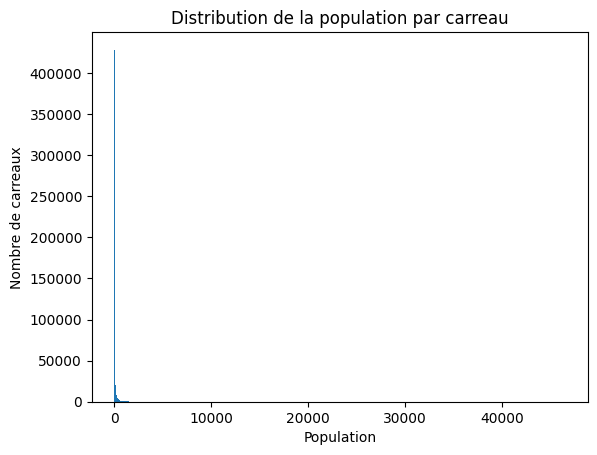

In [7]:
gdf["ind"].plot(kind="hist", bins=1000, title="Distribution de la population par carreau", xlabel="Population", ylabel="Nombre de carreaux")

Plusieurs types de valeurs :

i_est_1km numérique 
- Vaut 2 si le carreau donne les vraies valeurs mais le nombre de ménages
affiché apparaît comme inférieur à 11 pour des questions d'arrondis (voir
Arrondis des valeurs à une décimale)
- Vaut 1 si le carreau est imputé par une valeur approchée,
- Vaut 0 dans les autres cas

source : https://www.insee.fr/fr/statistiques/7655513?sommaire=7655515  Documentation méthodo

Text(0, 0.5, 'Nombre de carreaux')

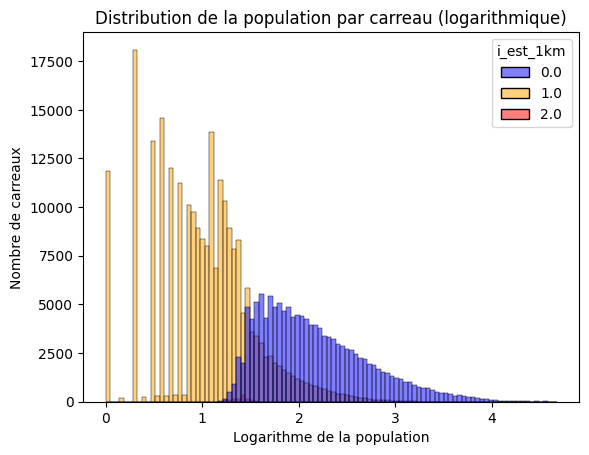

In [8]:
gdf['log(ind)'] = gdf["ind"].apply(np.log10)


ax = sns.histplot(data=gdf, 
             x="log(ind)",
             hue="i_est_1km",
             palette=["blue", "orange", "red"],
             bins=100,
             kde=False)

ax.set_title("Distribution de la population par carreau (logarithmique)")
ax.set_xlabel("Logarithme de la population")
ax.set_ylabel("Nombre de carreaux")


Text(0, 0.5, 'Nombre de carreaux')

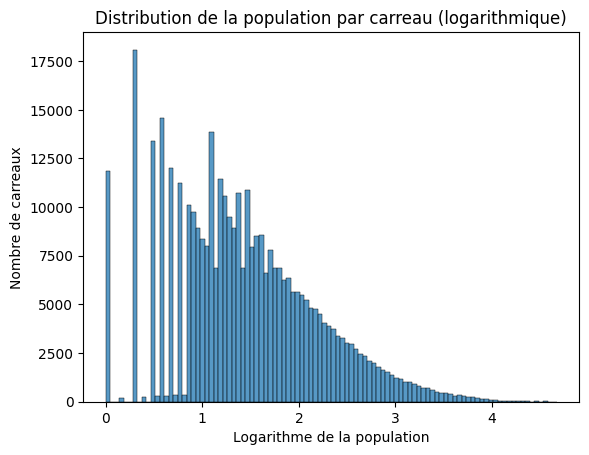

In [13]:
ax = sns.histplot(data=gdf, 
             x="log(ind)",
             bins=100,
             kde=False)

ax.set_title("Distribution de la population par carreau (logarithmique)")
ax.set_xlabel("Logarithme de la population")
ax.set_ylabel("Nombre de carreaux")

Text(0, 0.5, '% de carreaux')

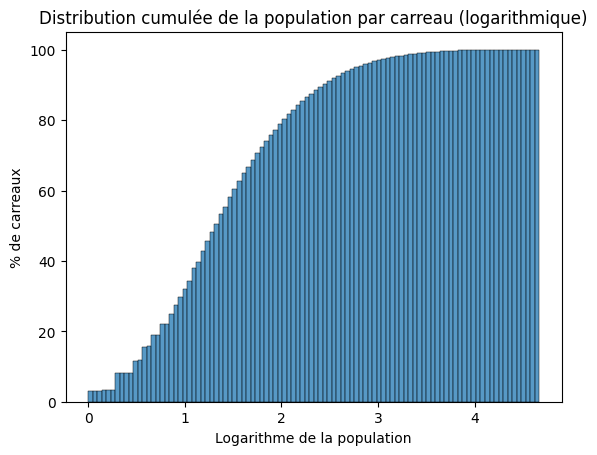

In [14]:
ax = sns.histplot(data=gdf, 
             x="log(ind)",
             stat="percent",
             cumulative=True,
             bins=100,
             kde=False)

ax.set_title("Distribution cumulée de la population par carreau (logarithmique)")
ax.set_xlabel("Logarithme de la population")
ax.set_ylabel("% de carreaux")

<Axes: >

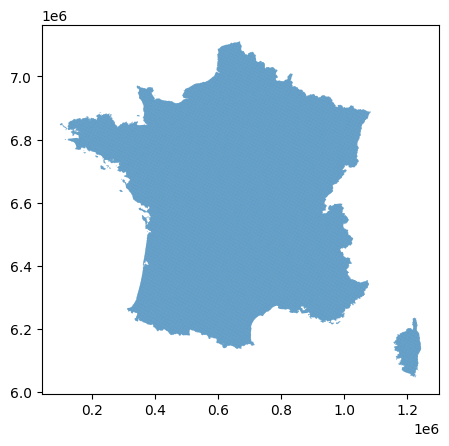

In [15]:
gdf.plot()

Commentaires :

- données cohérentes : la densité à Paris est de 43 000 hab / km2 (log=4)
- 60% du territoire carroyé vit avec moins de 100 hab au km2
- 70% du territoire est couvert